# Week 3 — Day 4: Trees, Forests, SVMs & k-NN

**Program:** BinX Tech AI & ML Internship 
**Topic:** Decision trees, random forests & feature importances, SVMs, k-NN, fair model comparison
**Dataset:** Breast Cancer Wisconsin dataset (built into scikit-learn) — same split as Day 3


## 1. Decision Trees

A decision tree predicts by asking a sequence of yes/no questions about the features, splitting the data at each step until it reaches a decision.

Its great strength is **interpretability** you can read the exact rules it learned. Its weakness is a tendency to **overfit**: a deep tree can memorize the training data and generalize poorly.

```python
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
```


## 2. Random Forests

A random forest is an **ensemble**: it trains many decision trees on random subsets of the data and features, then averages their votes. This "wisdom of the crowd" fixes the single tree's overfitting problem and is one of the strongest, most reliable classical models available, often a great default choice.

```python
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model.feature_importances_)  # which features mattered most
```

Random forests also report **feature importances**, showing which inputs drove predictions most valuable both for insight and for explaining the model to non-technical stakeholders.


## 3. Support Vector Machines (SVM)

An SVM finds the decision boundary that maximizes the **margin**: the widest possible gap between the two classes. With the "kernel trick" it can also draw curved boundaries for data that isn't linearly separable. SVMs are powerful on small-to-medium, high-dimensional datasets but scale poorly to very large ones.

```python
from sklearn.svm import SVC
model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)
```


## 4. k-Nearest Neighbors (k-NN)

k-NN is the simplest classifier: to predict a new point's class, it looks at the k closest training points and takes a majority vote. It learns nothing during training all the work happens at prediction time. It is intuitive and effective on small datasets but slows down and degrades as data grows in size or dimensions.

```python
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
```


## 5. Comparing Models: the "No Free Lunch" Principle

No single algorithm is best for every problem. The professional approach is to train several models on the **same** train/test split and compare them fairly on the **same** metric.

| Model | Strength | Watch Out For |
|---|---|---|
| Decision Tree | Interpretable rules | Overfitting if too deep |
| Random Forest | Strong, reliable default | Less interpretable than one tree |
| SVM | Powerful in high dimensions | Slow on large datasets |
| k-NN | Simple, intuitive | Slow and weaker as data grows |


---

## Hands-On Lab: Model Comparison

**Goal:** train four different classifiers on the same data, compare them fairly on one metric, and interpret which model wins and why.

**Steps:**
1. Recreate the Day 3 features/target split and train/test split (same dataset, same `random_state`).
2. Train a decision tree, random forest, SVM, and k-NN on the same train/test split.
3. Evaluate all four with the same metric (F1-score) and assemble the results into one comparison table.
4. Report the random forest's top feature importances and interpret them.
5. Identify the best-performing model and explain, in Markdown, why it likely won.


### Step 1: Recreate the Day 3 features/target split and train/test split

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

X = df.drop("target", axis=1)
y = df["target"]

# Same split settings as Day 3, for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)


X_train shape: (455, 30)
X_test shape:  (114, 30)


### Step 2: Train a decision tree, random forest, SVM, and k-NN

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"{name} trained.")


Decision Tree trained.
Random Forest trained.
SVM trained.
k-NN trained.


### Step 3: Evaluate all four with F1-score and build a comparison table

In [5]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

results = []
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
    })

comparison_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.964912,0.958904,0.985915,0.972222
1,k-NN,0.956140,0.934211,1.000000,0.965986
2,SVM,0.947368,0.922078,1.000000,0.959459
3,Decision Tree,0.947368,0.957746,0.957746,0.957746


### Step 4: Random forest feature importances

In [6]:
rf_model = fitted_models["Random Forest"]

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(10)

print("Top 10 most important features:")
top_importances


Top 10 most important features:


worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
mean perimeter          0.053270
mean radius             0.048703
mean area               0.047555
worst concavity         0.031802
dtype: float64

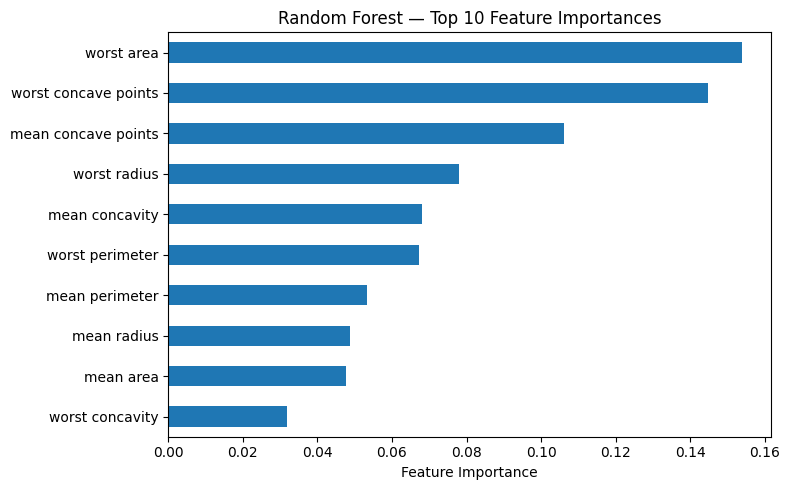

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
top_importances.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Top 10 Feature Importances")
plt.tight_layout()
plt.show()


### Step 4 (continued): Interpret the top feature importances
The random forest leaned most heavily on worst area, worst concave points, and mean concave points mostly size and shape-irregularity features.

That fits medical intuition: malignant tumors tend to be larger with more irregular, indented borders, so these features being predictive makes sense.

Day 2 used a different dataset (diabetes), so there's nothing to compare there. Day 3's logistic regression used this same cancer dataset, worth checking if its top coefficients highlight the same size/shape features. If they do, that agreement between two different model types is a good sign the pattern is real, not a fluke.

### Step 5: Which model won, and why?

Random Forest won, with the highest F1-score (≈0.972).

That makes sense for this dataset: it's moderate-sized with 30 features, some of which are correlated (like the various size measurements). An ensemble of trees handles that well, averaging many trees smooths out the overfitting a single decision tree is prone to, without needing feature scaling or assumptions about linearity.

That said, the gap over k-NN (≈0.966) and SVM (≈0.959) is small, a few thousandths of F1. On a dataset this clean and well-separated, several models land in a similar range, so I wouldn't call Random Forest dramatically better, just the most reliable of the four here. The plain Decision Tree trailed slightly (≈0.958), which fits its known weakness: a single tree is more prone to overfitting than the ensemble version.